In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow


Defaulting to user installation because normal site-packages is not writeable


2026-06-29 15:58:19.915190: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-29 15:58:21.065946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-29 15:58:24.040176: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


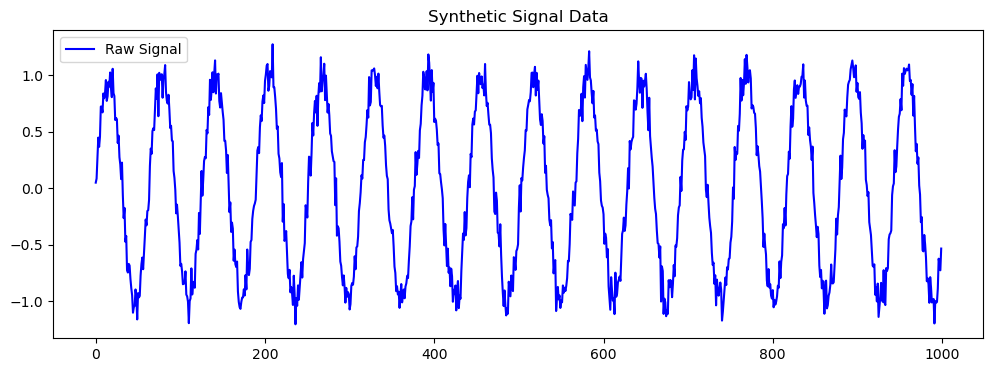

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Generate a synthetic signal (Sine wave with noise)
np.random.seed(42)
time = np.arange(0, 100, 0.1)
signal = np.sin(time) + np.random.normal(0, 0.1, len(time))

# Plot the generated signal
plt.figure(figsize=(12, 4))
plt.plot(signal, label="Raw Signal", color='blue')
plt.title("Synthetic Signal Data")
plt.legend()
plt.show()

In [3]:

# Normalize the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_signal = scaler.fit_transform(signal.reshape(-1, 1))

# Create training windows
def create_dataset(data, window_size=50):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 50
X, y = create_dataset(scaled_signal, WINDOW_SIZE)

# Split into Train and Test sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be [samples, time steps, features] required for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Training shape: (760, 50, 1), Testing shape: (190, 50, 1)


In [4]:
# Build the LSTM Architecture
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1) # Predicting the next continuous value
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
history = model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

2026-06-29 15:58:53.945017: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/iteradmin/.local/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.2268 - val_loss: 0.0397
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0333 - val_loss: 0.0058
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0079 - val_loss: 0.0029
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0070 - val_loss: 0.0024
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0059 - val_loss: 0.0022
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0053 - val_loss: 0.0021
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0044 - val_loss: 0.0020
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0045 - val_loss: 0.0019
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0048 - val_loss: 0.0020
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0048 - val_loss: 0.0028
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


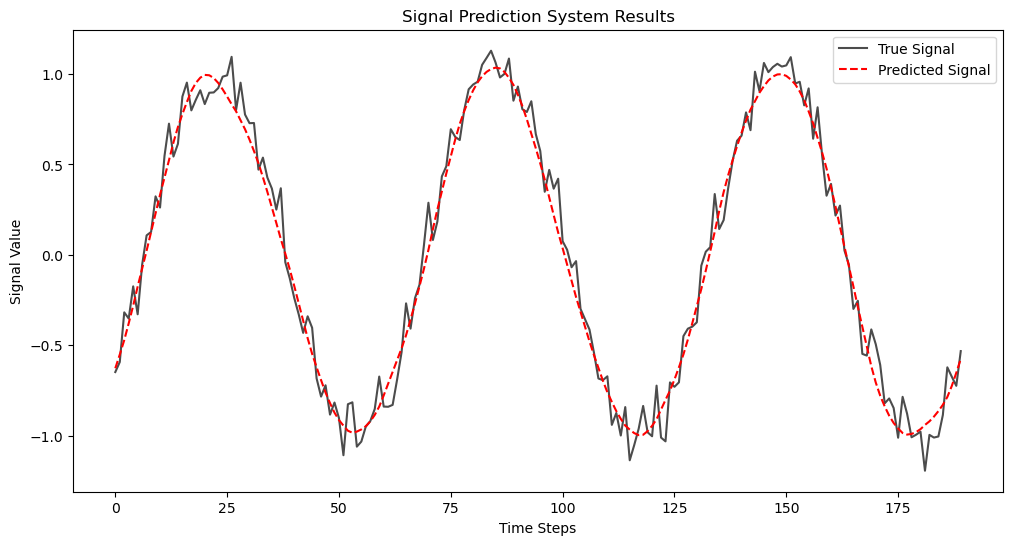

In [5]:
# Make predictions
predictions = model.predict(X_test)

# Invert normalization back to original scale
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="True Signal", color='black', alpha=0.7)
plt.plot(predictions_actual, label="Predicted Signal", color='red', linestyle='--')
plt.title("Signal Prediction System Results")
plt.xlabel("Time Steps")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=50, # You can set this higher now
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop], # Add it here
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0041 - val_loss: 0.0017
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0046 - val_loss: 0.0030
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0050 - val_loss: 0.0019
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0039 - val_loss: 0.0021


In [8]:
def predict_future_steps(model, initial_window, steps_to_predict):
    future_predictions = []
    # Start with the last known window from your test data
    current_window = initial_window.copy() 
    
    for _ in range(steps_to_predict):
        # Predict the next single step
        pred = model.predict(current_window.reshape(1, WINDOW_SIZE, 1), verbose=0)
        future_predictions.append(pred[0, 0])
        
        # Shift the window forward: drop the first value, append the predicted value
        current_window = np.append(current_window[1:], pred)
        
    return np.array(future_predictions)

# Let's predict 20 steps into the unknown future
last_test_window = X_test[-1] 
future_forecast_scaled = predict_future_steps(model, last_test_window, steps_to_predict=20)

# Unscale the future predictions
future_forecast = scaler.inverse_transform(future_forecast_scaled.reshape(-1, 1))

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
mape = mean_absolute_percentage_error(y_test_actual, predictions_actual)

print(f"--- Model Performance ---")
print(f"RMSE (Average deviation): {rmse:.4f}")
print(f"MAPE (Average % error): {mape * 100:.2f}%")

--- Model Performance ---
RMSE (Average deviation): 0.1067
MAPE (Average % error): 28.39%


In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create UI Elements
steps_slider = widgets.IntSlider(value=10, min=5, max=50, step=5, description='Future Steps:')
predict_button = widgets.Button(description='Generate Forecast', button_style='success')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output() # Clears the previous plot
        
        steps = steps_slider.value
        print(f"Running recursive forecast for the next {steps} steps...")
        
        # 1. Run the future forecast function
        last_test_window = X_test[-1]
        future_forecast_scaled = predict_future_steps(model, last_test_window, steps_to_predict=steps)
        future_forecast = scaler.inverse_transform(future_forecast_scaled.reshape(-1, 1))
        
        # 2. Plot the results dynamically
        plt.figure(figsize=(10, 5))
        plt.plot(y_test_actual[-50:], label="Recent True Signal", color='black')
        
        # Construct an index for the future timeline
        future_index = np.arange(len(y_test_actual[-50:]), len(y_test_actual[-50:]) + steps)
        plt.plot(future_index, future_forecast, label="Predicted Future", color='red', linestyle='--')
        
        plt.title(f"Interactive {steps}-Step Ahead Forecast")
        plt.legend()
        plt.show()

# Connect the button click to the function
predict_button.on_click(on_button_clicked)

# Display the Dashboard
print("--- SIGNAL PREDICTION SYSTEM DASHBOARD ---")
display(widgets.HBox([steps_slider, predict_button]))
display(output)

--- SIGNAL PREDICTION SYSTEM DASHBOARD ---


Output()